# Initial Summary Statistics

## Data Prep

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Load Dataset

In [2]:
hurricanes = pd.read_csv("data/hurricane_data.csv") # renamed kaggle csv from storms to hurricane_data

### Inspect Dataset

In [3]:
print(hurricanes.head())
print(hurricanes.info())
print(hurricanes.columns)

       name  year  month  day  hour   lat  long               status  \
0  AL011975  1975      6   24    12  32.5 -52.0  tropical depression   
1  AL011975  1975      6   24    18  32.6 -52.6  tropical depression   
2  AL011975  1975      6   25     0  32.7 -53.2  tropical depression   
3  AL011975  1975      6   25    60  32.8 -53.2  tropical depression   
4  AL011975  1975      6   25    12  33.0 -54.5  tropical depression   

   category  wind  pressure  tropicalstorm_force_diameter  \
0       NaN    20      -999                         -1998   
1       NaN    25      -999                         -1998   
2       NaN    25      -999                         -1998   
3       NaN    25      -999                         -1998   
4       NaN    25      -999                         -1998   

   hurricane_force_diameter  
0                     -1998  
1                     -1998  
2                     -1998  
3                     -1998  
4                     -1998  
<class 'pandas.core.

### Handle Missing Values

In [4]:
# Replace NOAA missing value placeholder codes with NaN
hurricanes.replace([-999, -1998, -99], np.nan, inplace=True)

# Check missing values
print(hurricanes.isnull().sum())

name                                0
year                                0
month                               0
day                                 0
hour                                0
lat                                 0
long                               14
status                              0
category                        17543
wind                               39
pressure                         1918
tropicalstorm_force_diameter    11439
hurricane_force_diameter        11439
dtype: int64


NOTES:
The values -99, -999 and -1998 in the NOAA hurricane dataset represent placeholder codes used to indicate missing or unavailable observations. During preprocessing, these values were replaced with null (NaN) values to ensure accurate missing value analysis and prevent invalid measurements from affecting the modeling process.

features with missing values
*   category - should filter on hurricanes only
*   pressure - possibly impute with mean, median or mode. (median - best with outliers, mode - best for categorical)
*   tropicalstorm_force_diameter - possibly impute
*   hurricane_force_diameter - possibly impute




## Summary Stats

### Summary Statistics: Storm Status Distribution

In [5]:
print(hurricanes['status'].value_counts())

status
tropical storm            7339
tropical depression       5352
hurricane                 5162
extratropical             2370
other low                 1623
subtropical storm          333
disturbance                214
subtropical depression     174
tropical wave              138
Name: count, dtype: int64


### Summary Statistics: Numberical Variables:

In [6]:
print(hurricanes.describe())

               year         month          day          hour           lat  \
count  22705.000000  22705.000000  22705.00000  22705.000000  22705.000000   
mean    2001.987932      8.689055     15.75098     22.528254     26.606276   
std       14.388083      1.353205      8.93909     22.556684     10.393664   
min     1975.000000      1.000000      1.00000      0.000000      7.000000   
25%     1990.000000      8.000000      8.00000     12.000000     18.000000   
50%     2003.000000      9.000000     16.00000     18.000000     26.000000   
75%     2015.000000      9.000000     24.00000     22.000000     33.400000   
max     2024.000000     12.000000     31.00000     94.000000     70.700000   

               long     category          wind      pressure  \
count  22691.000000  5162.000000  22666.000000  20787.000000   
mean     -61.252069     1.892871     48.322598    993.414586   
std       21.176148     1.149691     25.254954     18.782900   
min     -136.900000     1.000000     10.0

NOTES:
*   Average month = 8
*   maximum hour value is 94 -- possible error given a exceeds 24hr
*   The latitude range 7.0 to 70.7
*   Hurricane category: mean 1.89, median 1, max 5

---


*   0°–10° Near the Equator / Tropical Atlantic

*   10°–20° Caribbean & Main Hurricane Development Region

*   20°–30° Gulf of Mexico / Florida / Bahamas

*   30°–40° Southeastern & Eastern U.S. Coast

*   40°–50° North Atlantic / Northeastern U.S.

*   50°–70° Northern Atlantic / Canada / Greenland region


### Summary Statistics for Wind and Pressure

In [7]:
print(hurricanes[['wind', 'pressure']].describe())

               wind      pressure
count  22666.000000  20787.000000
mean      48.322598    993.414586
std       25.254954     18.782900
min       10.000000    882.000000
25%       30.000000    986.000000
50%       40.000000   1000.000000
75%       60.000000   1007.000000
max      165.000000   1024.000000


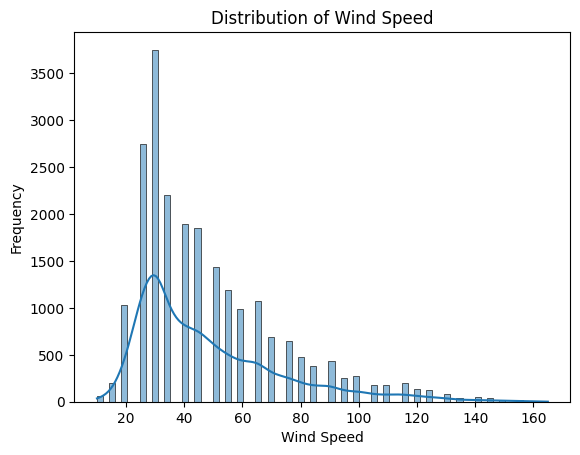

In [8]:
sns.histplot(hurricanes['wind'], kde=True)

plt.title("Distribution of Wind Speed")
plt.xlabel("Wind Speed")
plt.ylabel("Frequency")

plt.show()

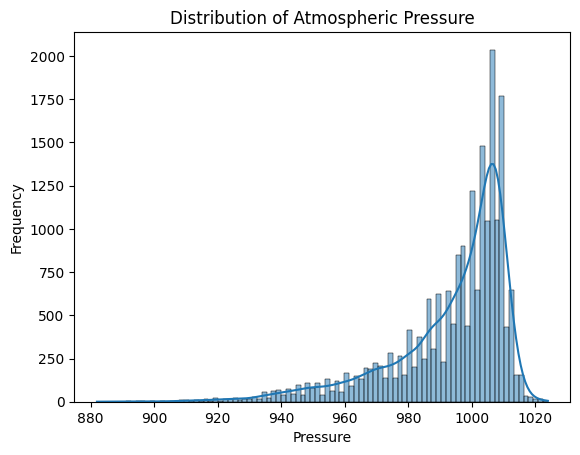

In [9]:
sns.histplot(hurricanes['pressure'], kde=True)

plt.title("Distribution of Atmospheric Pressure")
plt.xlabel("Pressure")
plt.ylabel("Frequency")

plt.show()

NOTES:

Most storms in the dataset had moderate wind speeds and relatively high atmospheric pressure, while a smaller number of storms reached extreme hurricane conditions. Wind speeds ranged from 10 mph to 165 mph, with most observations concentrated between 30 and 60 mph. The wind speed distribution is right-skewed, meaning there are fewer extremely intense storms compared to weaker storms.

The atmospheric pressure distribution shows that most storms had pressure values near 1000 mb, while a smaller number of storms had much lower pressure values. Since lower atmospheric pressure is generally associated with stronger hurricanes, the left tail of the distribution likely represents major hurricanes and intense storm systems.

### Summary Statistics: Category Distribution


In [10]:
print(hurricanes['category'].value_counts())

category
1.0    2744
2.0    1071
3.0     632
4.0     586
5.0     129
Name: count, dtype: int64


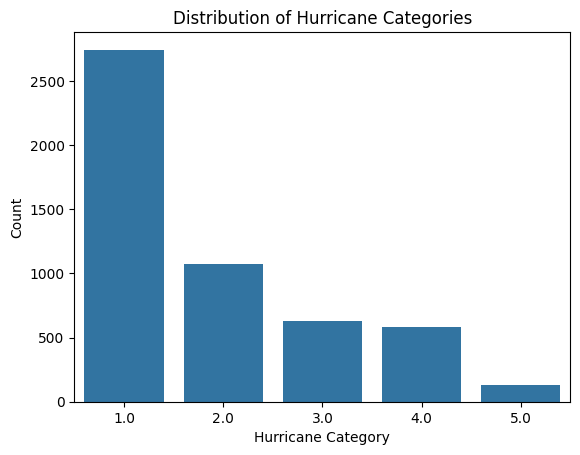

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='category', data=hurricanes)

plt.title("Distribution of Hurricane Categories")
plt.xlabel("Hurricane Category")
plt.ylabel("Count")

plt.show()

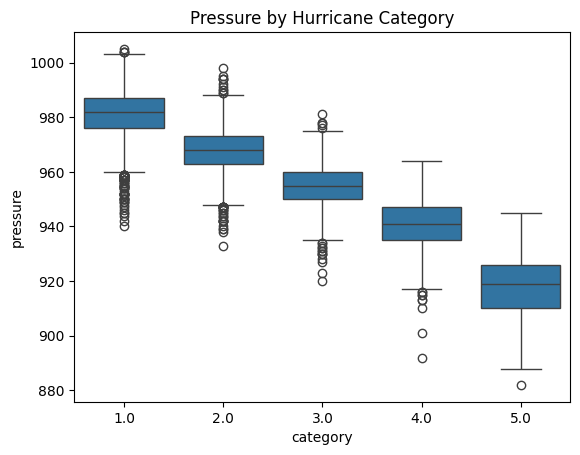

In [12]:
sns.boxplot(x='category', y='pressure', data=hurricanes)

plt.title("Pressure by Hurricane Category")

plt.show()

NOTES:

Lower-category hurricanes occur much more frequently than stronger hurricanes. Category 1 hurricanes make up the largest portion of the dataset, while Category 5 hurricanes are relatively rare.

This indicates a class imbalance within the data, which is common in hurricane datasets because extreme storms occur less often than weaker storms.

The pressure boxplot shows a clear relationship between hurricane category and atmospheric pressure. As hurricane category increases, atmospheric pressure generally decreases. Category 1 hurricanes tend to have higher pressure values, while Categories 4 and 5 show much lower pressure levels. This pattern supports the idea that lower atmospheric pressure is associated with stronger hurricanes and suggests that pressure may be an important predictor variable for hurricane severity classification models.

The boxplot also shows some variability and outliers within each category, indicating that storms within the same category can still differ in pressure and overall intensity.

NOTES: The storm status distribution shows that most observations in the dataset are classified as tropical storms, tropical depressions, or hurricanes. Tropical storms represent the largest group, followed closely by tropical depressions and hurricanes. This indicates that the dataset captures storms throughout multiple stages of development rather than only at peak hurricane intensity.

### Summary Statistics: Storm Correlation

In [13]:
correlation_matrix = hurricanes.corr(numeric_only=True)

print(correlation_matrix)

                                  year     month       day      hour  \
year                          1.000000 -0.015537 -0.021302  0.009973   
month                        -0.015537  1.000000 -0.164694  0.000232   
day                          -0.021302 -0.164694  1.000000 -0.000918   
hour                          0.009973  0.000232 -0.000918  1.000000   
lat                           0.023817 -0.030127 -0.029223  0.000725   
long                          0.036965  0.108308  0.023567 -0.008744   
category                      0.097078 -0.015781 -0.084152  0.010385   
wind                          0.083462  0.129675 -0.025178  0.012953   
pressure                     -0.024283 -0.149525  0.024065 -0.011977   
tropicalstorm_force_diameter  0.003764  0.142267 -0.008331  0.006198   
hurricane_force_diameter     -0.036938  0.108255 -0.005564  0.005099   

                                   lat      long  category      wind  \
year                          0.023817  0.036965  0.097078  0.0

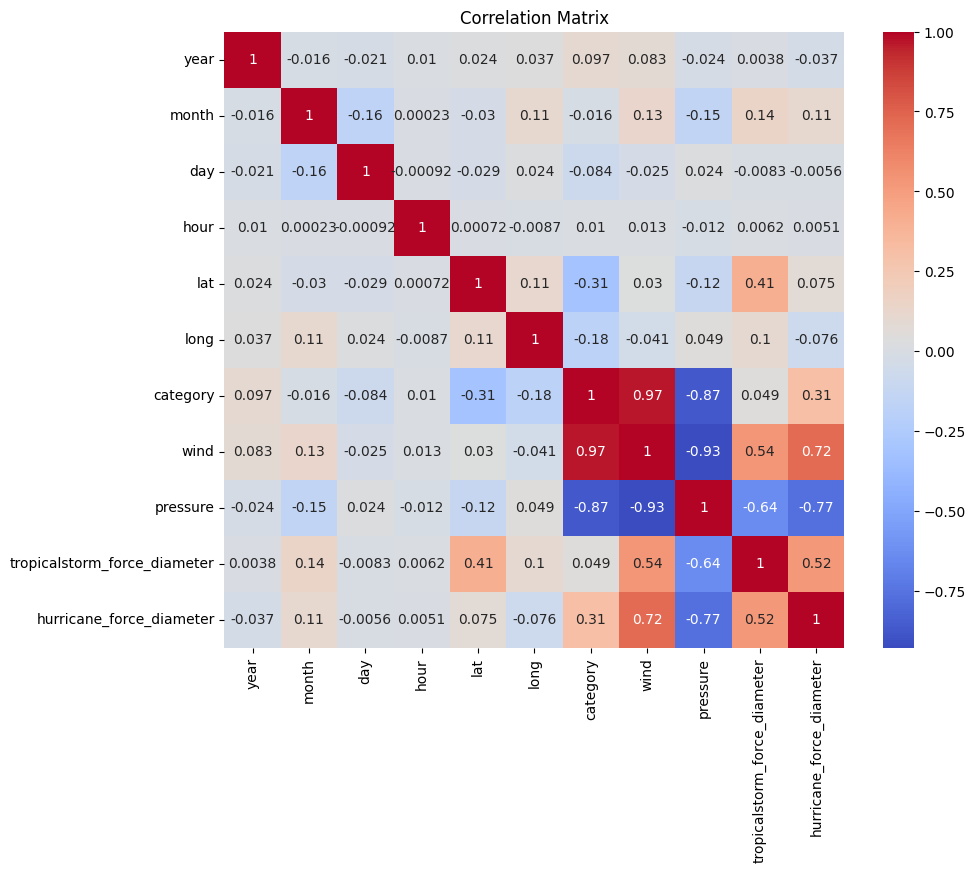

In [14]:
numeric_cols = hurricanes.select_dtypes(include='number')

corr = numeric_cols.corr()

plt.figure(figsize=(10,8))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

NOTES:

The correlation matrix shows several strong relationships between hurricane intensity variables, particularly among hurricane category, wind speed, and atmospheric pressure. The strongest positive correlation appears between hurricane category and wind speed (0.97), indicating that stronger hurricane categories are closely associated with higher wind speeds.

Atmospheric pressure shows a strong negative correlation with both hurricane category (-0.87) and wind speed (-0.93). This means that as wind speed and hurricane intensity increase, atmospheric pressure generally decreases.

The hurricane force diameter variable also shows a moderately strong positive relationship with wind speed (0.72), suggesting that storms with stronger winds tend to have larger hurricane-force wind fields. Similarly, tropical storm force diameter has a moderate positive correlation with wind speed (0.54), indicating that larger storms may also be associated with increased storm intensity.

Most temporal variables such as year, month, day, and hour show relatively weak correlations with hurricane intensity variables, suggesting that storm strength is more strongly influenced by environmental and storm-specific characteristics rather than calendar-based variables alone.

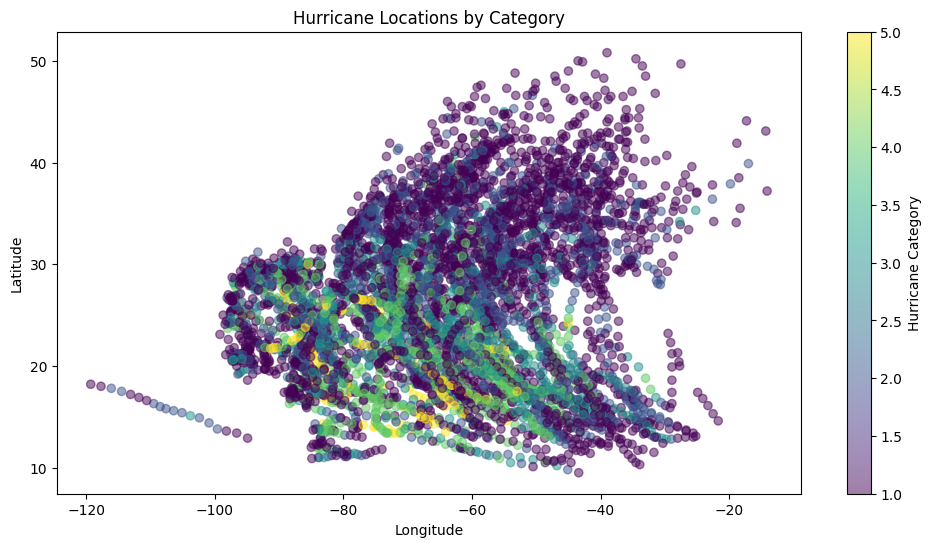

In [15]:
plt.figure(figsize=(12,6))

scatter = plt.scatter(
    hurricanes['long'],
    hurricanes['lat'],
    c=hurricanes['category'],
    cmap='viridis',
    alpha=0.5
)

plt.colorbar(scatter, label='Hurricane Category')

plt.title("Hurricane Locations by Category")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

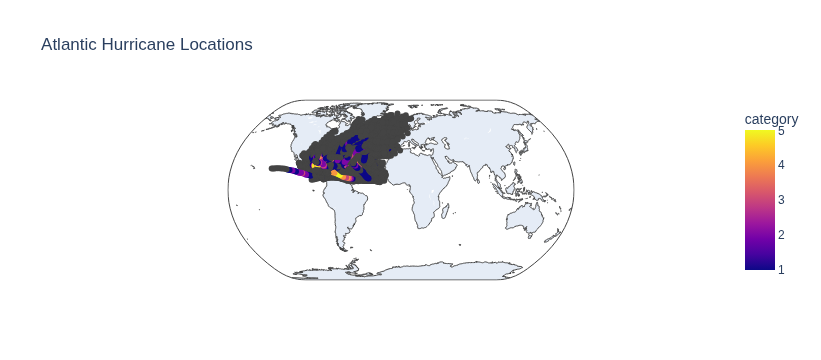

In [16]:
import plotly.express as px

fig = px.scatter_geo(
    hurricanes,
    lat='lat',
    lon='long',
    color='category',
    hover_name='name',
    projection='natural earth',
    title='Atlantic Hurricane Locations'
)

fig.show()